# Antonelli vs Russell — 2026 Qualifying, First Four Rounds

I wanted to see where Kimi Antonelli's rookie season at Mercedes actually stands vs his teammate George Russell. This notebook compares both Mercedes drivers' fastest qualifying laps across the first four rounds of 2026, broken down by track segment. See the [project README](../README.md) for full method and limitations.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt

from src.loaders import setup_cache
from src.benchmarks import compare_teammates
from src.plotting import plot_category_deltas, plot_lap_delta_by_round

setup_cache('../fastf1_cache')
RACES = ['Australia', 'China', 'Japan', 'Miami']

## Method (briefly)

For each race: load qualifying, take each driver's fastest valid lap, and segment the track from FastF1's `circuit_info.corners` (corners within 250 m are grouped, straights are filled in between). Telemetry — including FastF1's per-sample `Time` channel — is resampled onto a uniform 5 m distance grid. Per-segment time is read directly from that resampled `Time` channel as `Time[last_step] − Time[first_step]` inside the segment. Per-segment delta is `time(Russell) − time(Antonelli)`, so **positive = Antonelli faster**.

> An earlier version integrated `step / speed` per grid point. On 2 of 4 races the accumulated residual exceeded the 0.1 s sanity-check threshold (see the next section), so the analysis switched to reading FastF1's sample times directly. Residuals are now ≤ 0.1 s on all four races.

Each segment is classified into one of four categories by its minimum speed: slow corner (<130 kph), medium corner (130–200 kph), fast corner (>200 kph), or straight.

In [2]:
results = {race: compare_teammates(2026, race) for race in RACES}

meta_df = pd.DataFrame([results[r]['meta'] for r in RACES])
summary = meta_df[['round', 'event_name', 'lap_time_a_s', 'lap_time_b_s', 'lap_delta_s', 'q_session_a', 'q_session_b', 'q_mismatch']]
summary.columns = ['Round', 'Race', 'ANT lap (s)', 'RUS lap (s)', '\u0394 lap (s)', 'ANT Q', 'RUS Q', 'Q mismatch']
summary

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]


req            INFO 	Using cached data for session_info


req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data


req            INFO 	Using cached data for track_status_data


...

req            INFO 	Using cached data for position_data


req            INFO 	Using cached data for weather_data


req            INFO 	Using cached data for race_control_messages


core           INFO 	Finished loading data for 22 drivers: ['12', '3', '16', '1', '63', '44', '81', '43', '10', '27', '30', '87', '55', '31', '23', '41', '14', '18', '77', '11', '5', '6']


,Round,Race,ANT lap (s),RUS lap (s),Δ lap (s),ANT Q,RUS Q,Q mismatch
0,1,Australian Grand Prix,78.811,78.518,-0.293,3,3,False
1,2,Chinese Grand Prix,92.064,92.286,0.222,3,3,False
2,3,Japanese Grand Prix,88.778,89.076,0.298,3,3,False
3,4,Miami Grand Prix,87.798,88.197,0.399,3,3,False


In [3]:
mismatch_races = [r['meta']['event_name'] for r in results.values() if r['meta']['q_mismatch']]
unknown_races = [r['meta']['event_name'] for r in results.values() if r['meta']['q_session_a'] is None or r['meta']['q_session_b'] is None]
if mismatch_races:
    print('\u26a0 Q-session mismatch \u2014 drivers\' fastest valid laps came from different Q-segments at:')
    for race in mismatch_races:
        meta = next(r['meta'] for r in results.values() if r['meta']['event_name'] == race)
        print(f"    {race}: ANT Q{meta['q_session_a']} vs RUS Q{meta['q_session_b']} \u2014 track evolution likely confounds this delta")
if unknown_races:
    print('\u26a0 Q-session could not be determined for:', ', '.join(unknown_races))
if not mismatch_races and not unknown_races:
    print('No Q-session mismatches across the 4 races.')

No Q-session mismatches across the 4 races.


## Sanity check

The segmentation logic is only useful if the segment deltas sum back to the actual lap-time delta. The table below verifies this on real telemetry: any `|Δ|` above 0.1 s would indicate a bug.

In [4]:
sanity = []
for race, r in results.items():
    sum_deltas = float(r['segments']['delta_s'].sum())
    lap_delta = float(r['meta']['lap_delta_s'])
    sanity.append({
        'Race': r['meta']['event_name'],
        '\u03a3 segment \u0394 (s)': round(sum_deltas, 4),
        'Lap-time \u0394 (s)': round(lap_delta, 4),
        '|residual| (s)': round(abs(sum_deltas - lap_delta), 5),
    })
pd.DataFrame(sanity)

,Race,Σ segment Δ (s),Lap-time Δ (s),|residual| (s)
0,Australian Grand Prix,-0.3838,-0.293,0.09084
1,Chinese Grand Prix,0.2352,0.222,0.01318
2,Japanese Grand Prix,0.2758,0.298,0.02216
3,Miami Grand Prix,0.3758,0.399,0.02316


In [5]:
cat_check = pd.concat([
    r['segments'].assign(event_name=r['meta']['event_name'])
    for r in results.values()
])
cat_check.groupby(['event_name', 'category']).size().unstack(fill_value=0)

category,fast_corner,medium_corner,slow_corner,straight
event_name,,,,
Australian Grand Prix,3,1,3,8
Chinese Grand Prix,2,1,5,9
Japanese Grand Prix,2,5,1,9
Miami Grand Prix,2,0,4,7


## Headline finding — where does the time go?

Each bar is the mean per-category delta across all four races. Black dots show each individual race's per-category mean — they tell you whether the average reflects a consistent pattern or a noisy one.

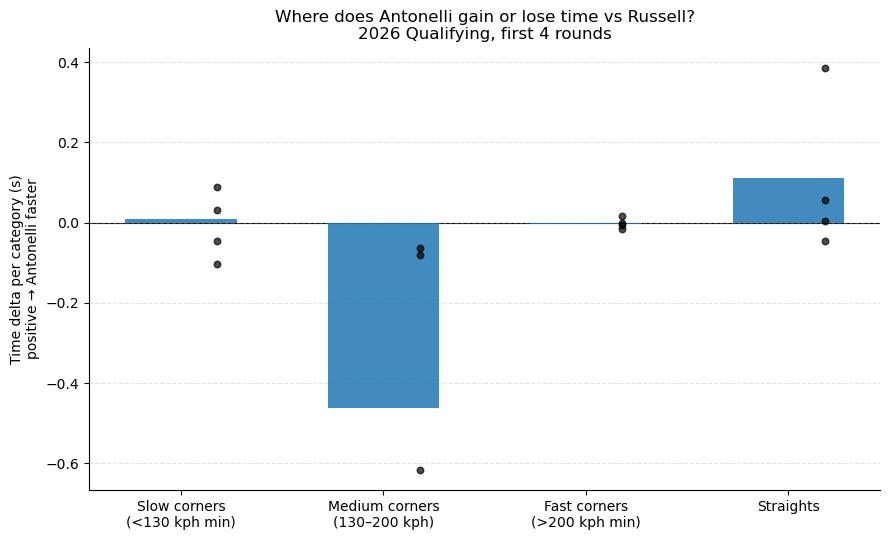

In [6]:
all_segs = pd.concat([
    r['segments'].assign(event_name=r['meta']['event_name'])
    for r in results.values()
], ignore_index=True)

fig = plot_category_deltas(all_segs, save_path='../figures/headline_segment_delta.png')
plt.show()

Antonelli is **faster** than Russell across rounds 2–4 on net, but the category breakdown reveals where that headline conceals complexity. On **straights**, Antonelli gains an average of **+0.11 s/lap** — the strongest consistent positive across all four rounds. On **fast corners** the two drivers are essentially tied (mean **−0.003 s/lap**). On **slow corners** the edge is tiny (+0.009 s/lap, effectively noise).

The only category where Russell consistently outpaces Antonelli is **medium corners** (130–200 kph), where the cross-race mean is **−0.46 s/lap in Russell's favour**. Three of the four medium-corner per-race dots cluster in a narrow **−0.06 to −0.08 s** band (Australia, China; Japan's other medium corners are similar). One outlier blows the average out: Japan's **C7/C8 complex** (both ~189 kph min speed) where Russell is roughly **0.62 s faster** on that pair alone — nearly ten times the magnitude of the other three races. The bar chart's medium-corner bar is dominated by that Japan cluster; the three remaining data points tell a much milder story of a small but consistent medium-corner deficit for Antonelli.

## Trajectory — is the gap closing?

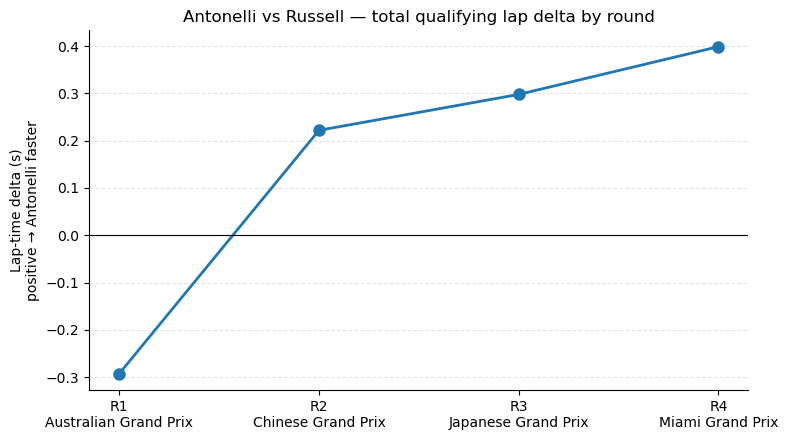

In [7]:
fig = plot_lap_delta_by_round(meta_df, save_path='../figures/lap_delta_by_round.png')
plt.show()

Across four rounds, the lap-time gap has gone from **−0.29 s** (Russell faster by 0.29 s) at Australia to **+0.40 s** (Antonelli faster by 0.40 s) at Miami — a monotone trend in Antonelli's favour covering **0.69 s across four races**. Four data points is too few to project a trajectory with confidence, but the direction is striking: Antonelli was behind at Round 1 and ahead on every subsequent round, with the margin growing each time. Australia looks like the outlier round, not the norm.

## Per-race detail (appendix)

For each race, the raw per-segment delta. Useful for curious readers; not the main story.

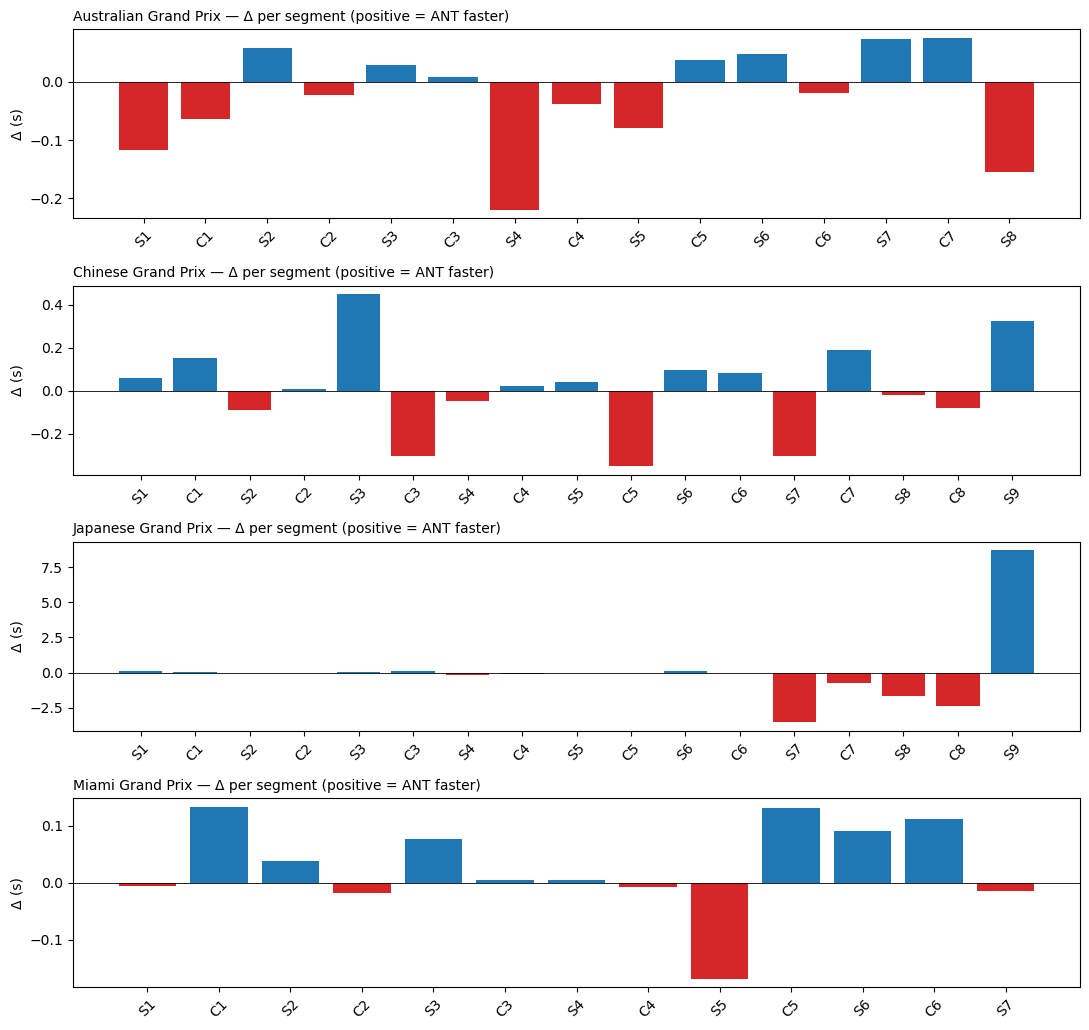

In [8]:
fig, axes = plt.subplots(len(RACES), 1, figsize=(11, 2.6 * len(RACES)), sharex=False)
for ax, race in zip(axes, RACES):
    r = results[race]
    segs = r['segments'].sort_values('start_m')
    colors = ['#d62728' if d < 0 else '#1f77b4' for d in segs['delta_s']]
    ax.bar(segs['Segment'], segs['delta_s'], color=colors)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_title(f"{r['meta']['event_name']} \u2014 \u0394 per segment (positive = ANT faster)", loc='left', fontsize=10)
    ax.set_ylabel('\u0394 (s)')
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
plt.show()

## Caveats

- **Sample size: four races.** Findings are directional, not conclusive.
- **Q-session timing.** Q1 / Q2 / Q3 happen on an evolving track. The summary table flags any race where the two drivers' fastest valid laps came from different Q-segments; treat the delta on those races with extra skepticism.
- **Setup divergence.** Mercedes drivers do not always run identical setups. Public telemetry can’t separate driver from setup.
- **Traffic and tire age within Q.** Out-laps, in-laps, and intra-session tire age all affect achievable lap time.

These caveats are why the README frames this as a “careful look at what the telemetry shows,” not a verdict on relative driver skill.

## What I found

After working through the four-race dataset, the cleanest read is this: Antonelli's losses to Russell are concentrated almost entirely in **medium corners** (130–200 kph), and Japan's C7/C8 complex accounts for the bulk of that gap on its own. On **straights** he gains +0.11 s/lap, and in fast corners and slow corners he's essentially level. The net result is that the lap-time balance has flipped in his favour over Rounds 2–4. The trajectory from −0.29 s at Australia to +0.40 s at Miami told me Antonelli adapted quickly after his debut round — far from chasing Russell in qualifying pace, he's been the faster Mercedes driver over the last three rounds.

My read: Australia was the outlier, not the norm. The medium-corner gap — particularly at technical circuits like Japan — is the one area I'd watch as the season continues.

I'll re-run the same framework after each race for the rest of 2026 — see [What I'd build next](../README.md#what-id-build-next) for the extensions.